In [1]:
import os
import glob
import json
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

os.makedirs("/workspace/models/ncf", exist_ok=True)
os.makedirs("/workspace/outputs/metrics", exist_ok=True)
os.makedirs("/workspace/outputs/figures", exist_ok=True)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

I0000 00:00:1777988350.243200      56 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777988352.965914      56 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0
GPU: []


In [2]:
def read_single_csv_from_spark_folder(folder):
    files = glob.glob(f"{folder}/part-*.csv")
    if not files:
        raise FileNotFoundError(f"No part csv found in {folder}")
    return pd.read_csv(files[0])

train_df = read_single_csv_from_spark_folder("/workspace/outputs/ncf/train_csv")
test_df = read_single_csv_from_spark_folder("/workspace/outputs/ncf/test_csv")

with open("/workspace/outputs/ncf/ncf_metadata.json", "r", encoding="utf-8") as f:
    metadata = json.load(f)

num_users = metadata["num_users"]
num_movies = metadata["num_movies"]

train_df.head(), test_df.head(), metadata

(   user_idx  movie_idx  label
 0         0         28      1
 1         0         49      1
 2         0        575      1
 3         0        751      0
 4         0        842      0,
    user_idx  movie_idx  label
 0         0        528      1
 1         0       1119      1
 2         0       1130      1
 3         0       2430      1
 4         0       3284      1,
 {'num_users': 25943,
  'num_movies': 27099,
  'num_positive_samples': 2000000,
  'negative_sampling_ratio': 1,
  'label_rule': 'rating >= 4.0 => positive'})

In [3]:
BATCH_SIZE = 8192

train_ds = tf.data.Dataset.from_tensor_slices((
    {
        "user_idx": train_df["user_idx"].astype("int32").values,
        "movie_idx": train_df["movie_idx"].astype("int32").values,
    },
    train_df["label"].astype("float32").values
)).shuffle(200_000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((
    {
        "user_idx": test_df["user_idx"].astype("int32").values,
        "movie_idx": test_df["movie_idx"].astype("int32").values,
    },
    test_df["label"].astype("float32").values
)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [4]:
from tensorflow.keras import layers, Model

EMBEDDING_DIM = 64

user_input = layers.Input(shape=(), name="user_idx", dtype=tf.int32)
movie_input = layers.Input(shape=(), name="movie_idx", dtype=tf.int32)

user_embedding = layers.Embedding(
    input_dim=num_users,
    output_dim=EMBEDDING_DIM,
    name="user_embedding"
)(user_input)

movie_embedding = layers.Embedding(
    input_dim=num_movies,
    output_dim=EMBEDDING_DIM,
    name="movie_embedding"
)(movie_input)

user_vec = layers.Flatten()(user_embedding)
movie_vec = layers.Flatten()(movie_embedding)

x = layers.Concatenate()([user_vec, movie_vec])
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(32, activation="relu")(x)

output = layers.Dense(1, activation="sigmoid")(x)

model = Model(inputs=[user_input, movie_input], outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user_idx            │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_idx           │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embedding      │ (None, 64)        │  1,660,352 │ user_idx[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_embedding     │ (None, 64)        │  1,734,336 │ movie_idx[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 64)        │          0 │ user_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 64)        │          0 │ movie_embedding[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128)       │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     16,512 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,080 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         33 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,421,569 (13.05 MB)

 Trainable params: 3,421,569 (13.05 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=2,
        restore_best_weights=True
    )
]

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 80s 200ms/step - accuracy: 0.8550 - auc: 0.9291 - loss: 0.3403 - val_accuracy: 0.8801 - val_auc: 0.9475 - val_loss: 0.2870
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 80s 203ms/step - accuracy: 0.8801 - auc: 0.9467 - loss: 0.2891 - val_accuracy: 0.8835 - val_auc: 0.9494 - val_loss: 0.2809
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 79s 203ms/step - accuracy: 0.8851 - auc: 0.9505 - loss: 0.2772 - val_accuracy: 0.8877 - val_auc: 0.9512 - val_loss: 0.2752
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 80s 204ms/step - accuracy: 0.8943 - auc: 0.9567 - loss: 0.2573 - val_accuracy: 0.8976 - val_auc: 0.9572 - val_loss: 0.2577
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 78s 200ms/step - accuracy: 0.9043 - auc: 0.9633 - loss: 0.2346 - val_accuracy: 0.9047 - val_auc: 0.9608 - val_loss: 0.2468
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 81s 207ms/step - accuracy: 0.9124 - auc: 0.9680 - loss: 0.2167 - val_accuracy: 0.9110 - val_auc: 0.9638 - val_loss: 0.2387
Epoch 7/10
391/391 ━━━

In [6]:
eval_result = model.evaluate(test_ds, return_dict=True)
eval_result

98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.9294 - auc: 0.9726 - loss: 0.2096


{'accuracy': 0.9293653964996338,
 'auc': 0.9725552797317505,
 'loss': 0.20964539051055908}

In [7]:
model.save("/workspace/models/ncf/ncf_model.keras")

ncf_metrics = {
    "model": "Neural Collaborative Filtering",
    "embedding_dim": EMBEDDING_DIM,
    "batch_size": BATCH_SIZE,
    **{k: float(v) for k, v in eval_result.items()}
}

with open("/workspace/outputs/metrics/ncf_metrics.json", "w", encoding="utf-8") as f:
    json.dump(ncf_metrics, f, ensure_ascii=False, indent=2)

ncf_metrics

{'model': 'Neural Collaborative Filtering',
 'embedding_dim': 64,
 'batch_size': 8192,
 'accuracy': 0.9293653964996338,
 'auc': 0.9725552797317505,
 'loss': 0.20964539051055908}

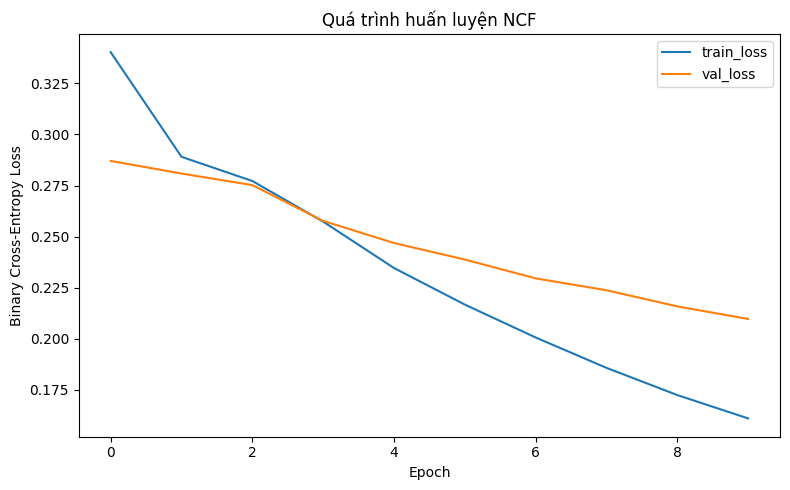

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Quá trình huấn luyện NCF")
plt.legend()
plt.tight_layout()
plt.savefig("/workspace/outputs/figures/ncf_training_loss.png", dpi=200)
plt.show()